c:\Users\suzukir\anaconda3\envs\dlenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 4パターンの比較検証を開始します (200枚 x 3ノイズ)


c:\Users\suzukir\anaconda3\envs\dlenv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\suzukir\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
`torch_dtype` is deprecated! Use `dtype` instead!
Evaluating: 100%|██████████| 200/200 [33:02<00:0


📁 CSVファイルへ結果を保存中: results_4patterns.csv

🏆 最終結果 (Accuracy) 🏆
 Eps (Single)   : 79.50%
 X0 (Single)    : 79.50%
 X0 (5-Step)    : 73.50%
 X0 (10-Step)   : 71.00%
✅ 比較グラフを 'acc_comparison_4patterns.png' として保存しました。


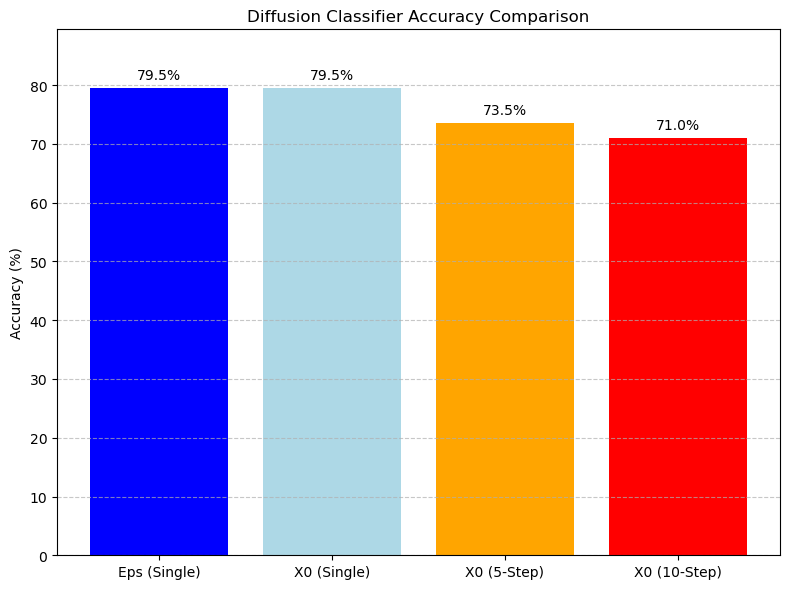

In [1]:
import os
import random
import torch
import torch.nn.functional as F
import numpy as np
import csv
from tqdm import tqdm
from collections import Counter
from torchvision import transforms, datasets
from diffusers import UNet2DConditionModel, DDPMScheduler, AutoencoderKL
from transformers import CLIPTextModel, CLIPTokenizer
import matplotlib.pyplot as plt

# ==========================================
# ★ 設定エリア
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16

# データセットパス
ANIMALS10_ROOT = r"C:\Users\suzukir\research\dataset\dataset\raw-img"
MODEL_ID = "runwayml/stable-diffusion-v1-5"

NUM_TEST_SAMPLES = 200  # テスト枚数
NUM_TRIALS = 3          # 1枚あたりのノイズ付加回数
SEED = 42

CSV_FILENAME = "results_4patterns.csv"

ITALIAN_TO_ENGLISH = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly",
    "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep",
    "ragno": "spider", "scoiattolo": "squirrel"
}
RAW_FOLDERS = sorted(list(ITALIAN_TO_ENGLISH.keys()))
CLASSES = [ITALIAN_TO_ENGLISH[f] for f in RAW_FOLDERS]

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

# ==========================================
# ★ 複数ステップの DDIM 再構成ヘルパー関数
# ==========================================
def get_multistep_x0(unet, x_t, t_start, class_embs, alphas_cumprod, num_steps):
    # t_start から 0 まで等間隔にタイムステップを刻む
    timesteps = np.linspace(t_start, 0, num_steps + 1, dtype=int)
    current_x = x_t.clone()
    
    for i in range(num_steps):
        t_curr = timesteps[i]
        t_next = timesteps[i+1]
        
        t_b = torch.full((x_t.shape[0],), t_curr, device=x_t.device, dtype=torch.long)
        pred_eps = unet(current_x, t_b, encoder_hidden_states=class_embs).sample
        
        alpha_bar_t = alphas_cumprod[t_curr].to(device)
        alpha_bar_next = alphas_cumprod[t_next].to(device)
        
        pred_x0 = (current_x - torch.sqrt(1 - alpha_bar_t) * pred_eps) / torch.sqrt(alpha_bar_t)
        
        if i == num_steps - 1:
            return pred_x0
            
        dir_xt = torch.sqrt(1 - alpha_bar_next) * pred_eps
        current_x = torch.sqrt(alpha_bar_next) * pred_x0 + dir_xt

    return current_x

# ==========================================
# ★ メイン実行部
# ==========================================
def run_comparison():
    print(f"🚀 4パターンの比較検証を開始します (200枚 x 3ノイズ)")
    set_seed(SEED)

    tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", torch_dtype=dtype).to(device)
    unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet", torch_dtype=dtype).to(device)
    vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", torch_dtype=dtype).to(device)
    scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")

    unet.eval(); text_encoder.eval(); vae.eval()
    alphas_cumprod = scheduler.alphas_cumprod

    with torch.no_grad():
        class_embs = torch.cat([
            text_encoder(tokenizer(f"a photo of a {c}", padding="max_length", max_length=77, return_tensors="pt").input_ids.to(device))[0] 
            for c in CLASSES
        ]).detach()

    val_tf = transforms.Compose([
        transforms.Resize((512, 512)), 
        transforms.ToTensor(), 
        transforms.Normalize([0.5], [0.5])
    ])
    dataset = datasets.ImageFolder(root=ANIMALS10_ROOT, transform=val_tf)
    sample_indices = random.sample(range(len(dataset)), min(NUM_TEST_SAMPLES, len(dataset)))

    correct = {"eps_1": 0, "x0_1": 0, "x0_5": 0, "x0_10": 0}
    
    # ★ CSV用のデータリスト
    csv_data = []

    pbar = tqdm(sample_indices, desc="Evaluating")

    for step, idx in enumerate(pbar):
        img_t, gt_idx = dataset[idx]
        gt_class = CLASSES[gt_idx]
        img_t = img_t.unsqueeze(0).to(device, dtype=dtype)
        
        with torch.no_grad():
            clean_lat = vae.encode(img_t).latent_dist.sample() * vae.config.scaling_factor
            clean_lat_b = clean_lat.repeat(len(CLASSES), 1, 1, 1)

            votes = {"eps_1": [], "x0_1": [], "x0_5": [], "x0_10": []}
            
            for trial in range(NUM_TRIALS):
                t_val = torch.randint(200, 701, (1,), device=device).long().item()
                noise = torch.randn_like(clean_lat)
                
                t_tensor = torch.tensor([t_val], device=device)
                noisy_lat = scheduler.add_noise(clean_lat, noise, t_tensor)
                
                n_b = noisy_lat.repeat(len(CLASSES), 1, 1, 1)
                noise_b = noise.repeat(len(CLASSES), 1, 1, 1)
                t_b = torch.full((len(CLASSES),), t_val, device=device, dtype=torch.long)

                # パターン1 & 2
                pred_eps_single = unet(n_b, t_b, encoder_hidden_states=class_embs).sample
                
                mse_eps_1 = F.mse_loss(pred_eps_single.float(), noise_b.float(), reduction="none").mean(dim=[1, 2, 3])
                votes["eps_1"].append(CLASSES[torch.argmin(mse_eps_1).item()])

                alpha_bar_t = alphas_cumprod[t_val].to(device)
                pred_x0_single = (n_b.float() - torch.sqrt(1 - alpha_bar_t) * pred_eps_single.float()) / torch.sqrt(alpha_bar_t)
                mse_x0_1 = F.mse_loss(pred_x0_single, clean_lat_b.float(), reduction="none").mean(dim=[1, 2, 3])
                votes["x0_1"].append(CLASSES[torch.argmin(mse_x0_1).item()])

                # パターン3
                pred_x0_5 = get_multistep_x0(unet, n_b, t_val, class_embs, alphas_cumprod, num_steps=5)
                mse_x0_5 = F.mse_loss(pred_x0_5.float(), clean_lat_b.float(), reduction="none").mean(dim=[1, 2, 3])
                votes["x0_5"].append(CLASSES[torch.argmin(mse_x0_5).item()])

                # パターン4
                pred_x0_10 = get_multistep_x0(unet, n_b, t_val, class_embs, alphas_cumprod, num_steps=10)
                mse_x0_10 = F.mse_loss(pred_x0_10.float(), clean_lat_b.float(), reduction="none").mean(dim=[1, 2, 3])
                votes["x0_10"].append(CLASSES[torch.argmin(mse_x0_10).item()])

            # 各パターンの多数決とCSV用データの保存
            row_dict = {
                "dataset_idx": idx,
                "ground_truth": gt_class
            }
            
            for key in correct.keys():
                final_vote = Counter(votes[key]).most_common(1)[0][0]
                row_dict[f"pred_{key}"] = final_vote
                row_dict[f"is_correct_{key}"] = (final_vote == gt_class)
                
                if final_vote == gt_class:
                    correct[key] += 1
                    
            csv_data.append(row_dict)
            
            # 進捗表示
            total_so_far = step + 1
            pbar.set_postfix({
                "e1": f"{(correct['eps_1']/total_so_far)*100:.1f}%",
                "x1": f"{(correct['x0_1']/total_so_far)*100:.1f}%",
                "x5": f"{(correct['x0_5']/total_so_far)*100:.1f}%",
                "x10": f"{(correct['x0_10']/total_so_far)*100:.1f}%"
            })

    # ★ CSVファイルの書き出し
    print(f"\n📁 CSVファイルへ結果を保存中: {CSV_FILENAME}")
    csv_headers = [
        "dataset_idx", "ground_truth", 
        "pred_eps_1", "is_correct_eps_1",
        "pred_x0_1", "is_correct_x0_1",
        "pred_x0_5", "is_correct_x0_5",
        "pred_x0_10", "is_correct_x0_10"
    ]
    with open(CSV_FILENAME, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=csv_headers)
        writer.writeheader()
        writer.writerows(csv_data)

    # 結果の可視化
    labels = ['Eps (Single)', 'X0 (Single)', 'X0 (5-Step)', 'X0 (10-Step)']
    accuracies = [
        (correct["eps_1"] / NUM_TEST_SAMPLES) * 100,
        (correct["x0_1"] / NUM_TEST_SAMPLES) * 100,
        (correct["x0_5"] / NUM_TEST_SAMPLES) * 100,
        (correct["x0_10"] / NUM_TEST_SAMPLES) * 100
    ]

    print("\n" + "=" * 50)
    print("🏆 最終結果 (Accuracy) 🏆")
    for label, acc in zip(labels, accuracies):
        print(f" {label:<15}: {acc:.2f}%")
    print("=" * 50)

    # 棒グラフの作成
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, accuracies, color=['blue', 'lightblue', 'orange', 'red'])
    plt.title('Diffusion Classifier Accuracy Comparison')
    plt.ylabel('Accuracy (%)')
    plt.ylim(0, max(accuracies) + 10 if max(accuracies) + 10 <= 100 else 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig("acc_comparison_4patterns.png")
    print("✅ 比較グラフを 'acc_comparison_4patterns.png' として保存しました。")

if __name__ == "__main__":
    run_comparison()